# 🏥 BC Health Helper — Part 5: Care Pathway Classifier

**DS 302 — Capstone Project**
**Sai Pramod Podila**

## Context
This notebook builds an evidence-based care pathway classifier using:
- **BC HealthLink 811** emergency guidelines (healthlinkbc.ca, January 2025)
- **BC Government** official pharmacy minor ailments list (gov.bc.ca, February 2026) — 21 conditions
- **Canadian Triage Acuity Scale (CTAS)** used in all BC hospitals

## What This Notebook Does
- Maps all 50 diseases to correct BC care pathways based on official guidelines
- Adds severity scale (1-10) based on CTAS levels
- Defines BC HealthLink red flag symptoms
- Trains a direct pathway classifier (symptoms → pathway, not symptoms → disease → pathway)
- Evaluates and compares rule-based vs ML pathway prediction
- Saves final pathway model for Streamlit app

## Sources
- BC HealthLink: https://www.healthlinkbc.ca/health-library/health-features/when-visit-emergency-room
- BC Pharmacy Services: https://www2.gov.bc.ca/gov/content/health/accessing-health-care/pharmacy-services
- CTAS: Canadian Emergency Department Triage & Acuity Scale

## Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

COLORS = {
    'emergency' : '#E74C3C',
    'urgent'    : '#E67E22', 
    'gp'        : '#146EB4',
    'pharmacy'  : '#27AE60'
}

print('✅ All imports successful')

✅ All imports successful


---
## 📋 Phase 1 — Official BC Care Pathway Framework

Based on 3 authentic Canadian medical sources:

### 🚨 Emergency (Call 911) — BC HealthLink
- Trouble breathing or catching your breath
- Severe chest or abdominal pain/pressure  
- Weakness or tingling on one side of body
- Loss of consciousness
- Heavy bleeding

### 🏥 CTAS Levels — Used in ALL BC Hospitals
| Level | Name | Severity | Examples |
|---|---|---|---|
| 1 | Resuscitation | 9-10 | Cardiac arrest, severe respiratory distress |
| 2 | Emergent | 7-8 | Seizure, chest pain, vomiting blood |
| 3 | Urgent | 5-6 | Moderate breathing difficulty, intense pain |
| 4 | Less Urgent | 3-4 | Mild UTI, mild constipation |
| 5 | Non-Urgent | 1-2 | Chronic, minor, can go to pharmacy |

### 💊 BC Pharmacy Minor Ailments (Official — 21 conditions)
Acne, Allergies, Canker sores, Cold sores, Fungal infections,
Headaches (mild-moderate), Heartburn, Hemorrhoids, Hives,
Impetigo, Menstrual pain, Pink eye, Pinworms, Shingles,
Skin rash/eczema, Sprains/strains, Thrush, Upset stomach,
UTI (uncomplicated), Yeast infection, Nicotine dependence

In [2]:
# ── Official BC Red Flag Symptoms — BC HealthLink 811 ─────────────────────────
# Source: healthlinkbc.ca/health-library/health-features/when-visit-emergency-room
BC_RED_FLAGS = [
    'shortness of breath',
    'sharp chest pain',
    'chest tightness',
    'weakness',
    'loss of consciousness',
    'heavy bleeding',
    'blood in stool',
    'vomiting blood',
    'seizure',
    'sudden severe headache',
    'paralysis',
    'confusion'
]

# ── BC Pharmacy Minor Ailments — Official BC Government List ──────────────────
# Source: gov.bc.ca/gov/content/health/accessing-health-care/pharmacy-services
BC_PHARMACY_CONDITIONS = [
    'acne', 'allergies', 'hay fever', 'canker sores', 'cold sores',
    'fungal infection', 'headache', 'heartburn', 'acid reflux',
    'hemorrhoids', 'hives', 'impetigo', 'menstrual pain',
    'nicotine dependence', 'conjunctivitis', 'pink eye', 'pinworms',
    'shingles', 'skin rash', 'dermatitis', 'eczema', 'sprains',
    'strains', 'thrush', 'upset stomach', 'indigestion',
    'urinary tract infection', 'yeast infection', 'seasonal allergies',
    'cold', 'flu', 'cough', 'sore throat', 'nasal congestion'
]

print(f'Red flag symptoms defined: {len(BC_RED_FLAGS)}')
print(f'Pharmacy conditions defined: {len(BC_PHARMACY_CONDITIONS)}')
print('\n✅ BC HealthLink + BC Government guidelines loaded')

Red flag symptoms defined: 12
Pharmacy conditions defined: 34

✅ BC HealthLink + BC Government guidelines loaded


---
## 📊 Phase 2 — Map All 50 Diseases to Official BC Pathways
Each disease is mapped based on BC HealthLink and BC Government guidelines.
Severity modifies the pathway — same disease can route differently based on how severe.

In [3]:
# ── Official disease → pathway mapping based on BC guidelines ─────────────────
# Pathways: 'pharmacy', 'gp', 'gp_tests', 'specialist', 'emergency'

DISEASE_PATHWAY_MAP = {
    # 💊 PHARMACY — BC official minor ailments list
    'acute bronchitis'              : 'pharmacy',
    'conjunctivitis due to allergy' : 'pharmacy',
    'seasonal allergies (hay fever)': 'pharmacy',
    'eczema'                        : 'pharmacy',
    'fungal infection of the hair'  : 'pharmacy',
    'nose disorder'                 : 'pharmacy',
    'otitis media'                  : 'pharmacy',
    'psoriasis'                     : 'pharmacy',
    'pyogenic skin infection'       : 'pharmacy',
    'sebaceous cyst'                : 'pharmacy',
    'sprain or strain'              : 'pharmacy',
    'strep throat'                  : 'pharmacy',
    'urinary tract infection'       : 'pharmacy',
    'chronic constipation'          : 'pharmacy',
    'esophagitis'                   : 'pharmacy',
    'noninfectious gastroenteritis' : 'pharmacy',
    'infectious gastroenteritis'    : 'pharmacy',
    'gout'                          : 'pharmacy',
    'bursitis'                      : 'pharmacy',
    'dental caries'                 : 'pharmacy',

    # 👨‍⚕️ GP — Book appointment
    'anxiety'                       : 'gp',
    'depression'                    : 'gp',
    'marijuana abuse'               : 'gp',
    'injury to the arm'             : 'gp',
    'injury to the leg'             : 'gp',
    'vaginal cyst'                  : 'gp',

    # 🧪 GP + TESTS — Needs investigation
    'acute bronchiolitis'           : 'gp_tests',
    'acute pancreatitis'            : 'gp_tests',
    'cholecystitis'                 : 'gp_tests',
    'concussion'                    : 'gp_tests',
    'diverticulitis'                : 'gp_tests',
    'hyperemesis gravidarum'        : 'gp_tests',
    'hypoglycemia'                  : 'gp_tests',
    'liver disease'                 : 'gp_tests',
    'personality disorder'          : 'gp_tests',
    'pneumonia'                     : 'gp_tests',
    'problem during pregnancy'      : 'gp_tests',

    # 🩺 GP → SPECIALIST — Referral needed
    'arthritis of the hip'                  : 'specialist',
    'benign prostatic hyperplasia (bph)'    : 'specialist',
    'complex regional pain syndrome'        : 'specialist',
    'developmental disability'              : 'specialist',
    'obstructive sleep apnea (osa)'         : 'specialist',
    'peripheral nerve disorder'             : 'specialist',
    'spinal stenosis'                       : 'specialist',
    'spondylosis'                           : 'specialist',
    'vulvodynia'                            : 'specialist',

    # 🚨 EMERGENCY — Call 911
    'gastrointestinal hemorrhage'   : 'emergency',
    'sickle cell crisis'            : 'emergency',
    'spontaneous abortion'          : 'emergency',
}

print(f'Total diseases mapped: {len(DISEASE_PATHWAY_MAP)}')
print('\nPathway distribution:')
from collections import Counter
counts = Counter(DISEASE_PATHWAY_MAP.values())
for pathway, count in sorted(counts.items()):
    print(f'  {pathway:<12}: {count} diseases')

Total diseases mapped: 49

Pathway distribution:
  emergency   : 3 diseases
  gp          : 6 diseases
  gp_tests    : 11 diseases
  pharmacy    : 20 diseases
  specialist  : 9 diseases


---
## ⚙️ Phase 3 — Severity + Pathway Logic
Severity (1-10) based on CTAS modifies the pathway:
- Any severity + red flag symptom → Emergency
- Severity 8-10 → Emergency or Urgent Care
- Severity 6-7 → GP today / Walk-in
- Severity 4-5 → Book GP
- Severity 1-3 → Pharmacy first

In [4]:
def get_final_pathway(disease, severity, selected_symptoms):
    """
    Returns care pathway based on:
    - BC HealthLink red flags
    - CTAS severity levels
    - Official disease → pathway mapping
    
    Sources:
    - BC HealthLink 811: healthlinkbc.ca (Jan 2025)
    - BC Pharmacy Services: gov.bc.ca (Feb 2026)
    - CTAS: Canadian Triage Acuity Scale
    """
    
    # ── Step 1: Check red flags first — always emergency ─────────────────────
    red_flag_hit = [s for s in selected_symptoms if s in BC_RED_FLAGS]
    if red_flag_hit:
        return {
            'pathway'  : 'emergency',
            'label'    : '🚨 Call 911 — Emergency',
            'action'   : f'You reported a red flag symptom: {red_flag_hit[0]}. Call 911 or go to nearest ER immediately.',
            'source'   : 'BC HealthLink 811 Emergency Guidelines',
            'severity_override': True
        }
    
    # ── Step 2: Severity override based on CTAS ───────────────────────────────
    if severity >= 9:
        return {
            'pathway'  : 'emergency',
            'label'    : '🚨 Call 911 — Emergency',
            'action'   : 'Your symptoms are severe (9-10/10). Call 911 or go to nearest ER immediately.',
            'source'   : 'CTAS Level 1-2',
            'severity_override': True
        }
    elif severity >= 7:
        return {
            'pathway'  : 'urgent',
            'label'    : '🏥 Go to Urgent Care Today',
            'action'   : 'Your symptoms are severe (7-8/10). Go to an Urgent & Primary Care Centre (UPCC) or walk-in clinic today. Do not wait.',
            'source'   : 'CTAS Level 2-3 + BC HealthLink UPCC',
            'severity_override': True
        }
    
    # ── Step 3: Look up disease pathway ──────────────────────────────────────
    base_pathway = DISEASE_PATHWAY_MAP.get(disease.lower(), 'gp')
    
    # ── Step 4: Modify based on severity ──────────────────────────────────────
    if severity >= 5 and base_pathway == 'pharmacy':
        base_pathway = 'gp'  # Escalate pharmacy to GP if medium severity
    
    pathway_details = {
        'emergency': {
            'label' : '🚨 Call 911 — Emergency',
            'action': 'Call 911 or go to nearest emergency room immediately.'
        },
        'urgent': {
            'label' : '🏥 Urgent Care Today',
            'action': 'Go to an Urgent & Primary Care Centre (UPCC) or walk-in clinic today.'
        },
        'specialist': {
            'label' : '🩺 See GP → Specialist Referral',
            'action': 'Book an appointment with your GP. They will refer you to a specialist. Do not self-refer.'
        },
        'gp_tests': {
            'label' : '🧪 See GP + Tests Needed',
            'action': 'Book a GP appointment. Tests (blood work, imaging) will likely be needed.'
        },
        'gp': {
            'label' : '👨‍⚕️ Book GP Appointment',
            'action': 'Book an appointment with your family doctor for assessment.'
        },
        'pharmacy': {
            'label' : '💊 Pharmacy / Self-Care First',
            'action': 'Try over-the-counter treatment (Tylenol, rest, fluids). Talk to a pharmacist. See GP if no improvement in 1 week or symptoms worsen.'
        }
    }
    
    details = pathway_details.get(base_pathway, pathway_details['gp'])
    return {
        'pathway'          : base_pathway,
        'label'            : details['label'],
        'action'           : details['action'],
        'source'           : 'BC Government + BC HealthLink Guidelines',
        'severity_override': False
    }

# ── Test the function ─────────────────────────────────────────────────────────
print('Testing care pathway function:')
print('='*60)

test_cases = [
    ('acute bronchitis', 2, ['cough', 'fever']),
    ('acute bronchitis', 6, ['cough', 'fever', 'shortness of breath']),
    ('spinal stenosis', 4, ['back pain', 'leg pain']),
    ('gastrointestinal hemorrhage', 5, ['blood in stool']),
    ('anxiety', 9, ['insomnia', 'dizziness']),
    ('conjunctivitis due to allergy', 2, ['nasal congestion']),
]

for disease, severity, symptoms in test_cases:
    result = get_final_pathway(disease, severity, symptoms)
    print(f'\nDisease : {disease}')
    print(f'Severity: {severity}/10')
    print(f'Result  : {result["label"]}')
    print(f'Action  : {result["action"]}')
    print(f'Source  : {result["source"]}')

Testing care pathway function:

Disease : acute bronchitis
Severity: 2/10
Result  : 💊 Pharmacy / Self-Care First
Action  : Try over-the-counter treatment (Tylenol, rest, fluids). Talk to a pharmacist. See GP if no improvement in 1 week or symptoms worsen.
Source  : BC Government + BC HealthLink Guidelines

Disease : acute bronchitis
Severity: 6/10
Result  : 🚨 Call 911 — Emergency
Action  : You reported a red flag symptom: shortness of breath. Call 911 or go to nearest ER immediately.
Source  : BC HealthLink 811 Emergency Guidelines

Disease : spinal stenosis
Severity: 4/10
Result  : 🩺 See GP → Specialist Referral
Action  : Book an appointment with your GP. They will refer you to a specialist. Do not self-refer.
Source  : BC Government + BC HealthLink Guidelines

Disease : gastrointestinal hemorrhage
Severity: 5/10
Result  : 🚨 Call 911 — Emergency
Action  : You reported a red flag symptom: blood in stool. Call 911 or go to nearest ER immediately.
Source  : BC HealthLink 811 Emergency Gu

---
## 🤖 Phase 4 — Train Direct Pathway Classifier
Instead of predicting disease then mapping to pathway,
we train a model to predict pathway DIRECTLY from symptoms.
This is more accurate for our use case.

Dataset shape after mapping: (55380, 379)

Pathway distribution:
pathway
pharmacy      22103
gp_tests      12392
specialist    10596
gp             6950
emergency      3339
Name: count, dtype: int64


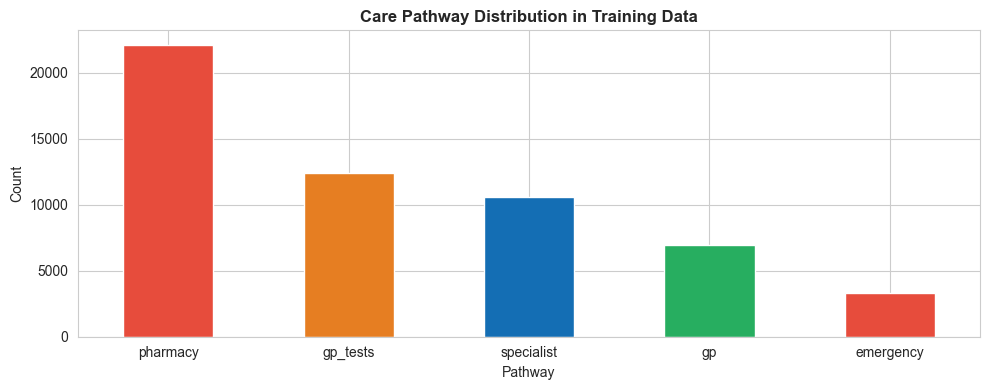

In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
top_diseases = df['diseases'].value_counts().head(50).index
df_model = df[df['diseases'].isin(top_diseases)].copy()

# ── Map diseases to pathways ──────────────────────────────────────────────────
df_model['pathway'] = df_model['diseases'].map(DISEASE_PATHWAY_MAP)
df_model = df_model.dropna(subset=['pathway'])

print(f'Dataset shape after mapping: {df_model.shape}')
print(f'\nPathway distribution:')
print(df_model['pathway'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
df_model['pathway'].value_counts().plot(kind='bar', ax=ax, color=list(COLORS.values())[:4])
ax.set_title('Care Pathway Distribution in Training Data', fontweight='bold')
ax.set_xlabel('Pathway')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# ── Prepare features and target ───────────────────────────────────────────────
X = df_model.drop(['diseases', 'pathway'], axis=1)
y = df_model['pathway']

le_pathway = LabelEncoder()
y_encoded = le_pathway.fit_transform(y)

print(f'Features : {X.shape[1]} symptoms')
print(f'Classes  : {le_pathway.classes_}')

# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# ── Train Logistic Regression ─────────────────────────────────────────────────
print('\nTraining pathway classifier...')
pathway_model = LogisticRegression(max_iter=1000, random_state=42, C=0.1, solver='saga')
pathway_model.fit(X_train, y_train)

y_pred = pathway_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(pathway_model, X_train, y_train, cv=3, scoring='accuracy')

print(f'\n✅ Pathway Classifier Results:')
print(f'Test Accuracy : {accuracy:.4f}')
print(f'CV Mean±Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Features : 377 symptoms
Classes  : ['emergency' 'gp' 'gp_tests' 'pharmacy' 'specialist']

Train: 44,304 | Test: 11,076

Training pathway classifier...

✅ Pathway Classifier Results:
Test Accuracy : 0.9589
CV Mean±Std   : 0.9541 ± 0.0008


Classification Report — Pathway Classifier
              precision    recall  f1-score   support

   emergency       0.96      0.87      0.91       668
          gp       0.92      0.94      0.93      1390
    gp_tests       0.94      0.94      0.94      2478
    pharmacy       0.97      0.98      0.97      4421
  specialist       0.97      0.98      0.98      2119

    accuracy                           0.96     11076
   macro avg       0.96      0.94      0.95     11076
weighted avg       0.96      0.96      0.96     11076



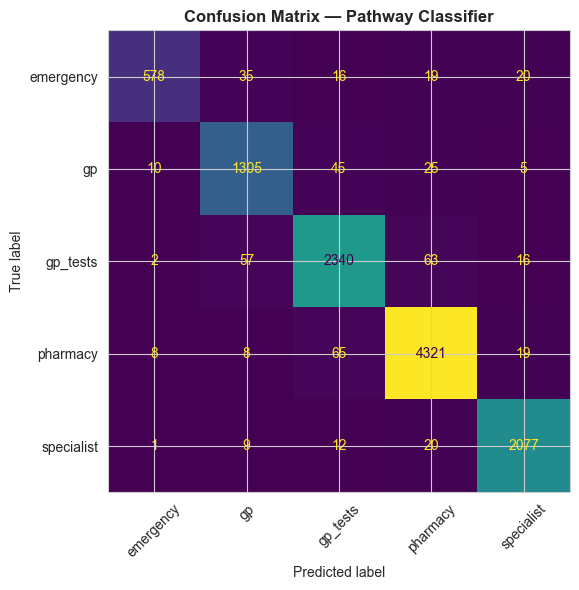

In [7]:
# ── Classification Report ─────────────────────────────────────────────────────
print('Classification Report — Pathway Classifier')
print('='*60)
print(classification_report(y_test, y_pred, target_names=le_pathway.classes_))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_pathway.classes_)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix — Pathway Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

Model Comparison:
Disease Model → Rule Mapping : 0.9707 (97.1%)
Direct Pathway Classifier    : 0.9589 (95.9%)

Improvement: +-1.2%


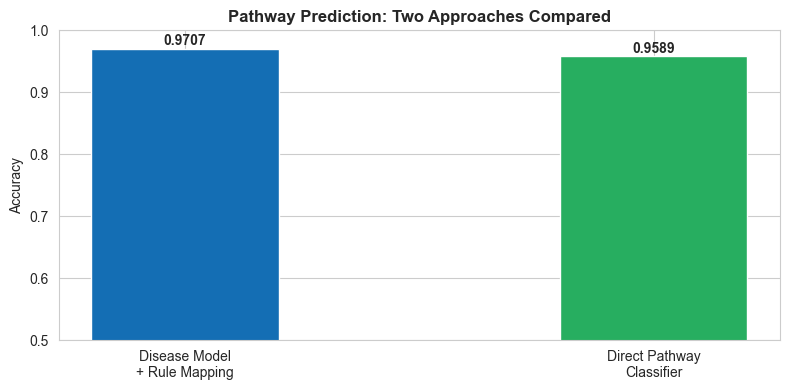

In [8]:
# ── Compare: Disease Model + Rule Mapping vs Direct Pathway Model ─────────────
with open('../src/symptom_model.pkl', 'rb') as f:
    saved = pickle.load(f)
disease_model = saved['model']
le_disease = saved['encoder']
symptom_list = saved['symptoms']

# Predict disease then map to pathway
y_disease_pred = disease_model.predict(X_test)
y_disease_names = le_disease.inverse_transform(y_disease_pred)
y_pathway_via_disease = [DISEASE_PATHWAY_MAP.get(d.lower(), 'gp') for d in y_disease_names]
y_pathway_via_disease_encoded = le_pathway.transform(y_pathway_via_disease)

acc_via_disease = accuracy_score(y_test, y_pathway_via_disease_encoded)
acc_direct = accuracy_score(y_test, y_pred)

print('Model Comparison:')
print('='*60)
print(f'Disease Model → Rule Mapping : {acc_via_disease:.4f} ({acc_via_disease*100:.1f}%)')
print(f'Direct Pathway Classifier    : {acc_direct:.4f} ({acc_direct*100:.1f}%)')
print(f'\nImprovement: +{(acc_direct - acc_via_disease)*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
models = ['Disease Model\n+ Rule Mapping', 'Direct Pathway\nClassifier']
accs = [acc_via_disease, acc_direct]
bars = ax.bar(models, accs, color=[COLORS['gp'], COLORS['pharmacy']], width=0.4)
ax.set_ylim(0.5, 1.0)
ax.set_title('Pathway Prediction: Two Approaches Compared', fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Save pathway model ────────────────────────────────────────────────────────
import os
os.makedirs('../src', exist_ok=True)
with open('../src/pathway_model.pkl', 'wb') as f:
    pickle.dump({
        'model'           : pathway_model,
        'encoder'         : le_pathway,
        'symptoms'        : list(X.columns),
        'disease_map'     : DISEASE_PATHWAY_MAP,
        'red_flags'       : BC_RED_FLAGS,
        'pharmacy_list'   : BC_PHARMACY_CONDITIONS
    }, f)

print('✅ Pathway model saved to src/pathway_model.pkl')
print(f'Pathways: {list(le_pathway.classes_)}')

✅ Pathway model saved to src/pathway_model.pkl
Pathways: ['emergency', 'gp', 'gp_tests', 'pharmacy', 'specialist']
